In [1]:
import polars as pl

import seaborn as sns

%load_ext autoreload
%autoreload 2

bcl2_scope_id = "d1g5ma_"
ced9_scope_id = "d1ty4b_"

In [2]:
results = pl.scan_csv(
    "/Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k15.scaled1.kmerseek.results.csv"
)

# Add SCOP ID columns by splitting query_name and target_name on whitespace
results = results.with_columns([
    pl.col("query_name").str.split(" ").list.get(0).alias("query_scop_id"),
    pl.col("target_name").str.split(" ").list.get(0).alias("target_scop_id"),
])

results.head().collect()

query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,overlap_probability,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_scop_id,target_scop_id
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str
"""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d58a8c87aaa1b040""","""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""8204b39e77e78976""",1.0,37,15,1,"""hp""",0.224242,1.0,4.472973,5.5,1.294197,0.224242,12.891892,182.731907,0.268498,0,15,"""EQVVAIASNIGGKQA""",163,178,"""EQVVAIASNGGGKQA""","""pphhhhhpphhhpph""",15,"""d2kq5a_""","""d3v6ta_"""
"""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d58a8c87aaa1b040""","""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""8204b39e77e78976""",1.0,37,15,1,"""hp""",0.224242,1.0,4.472973,5.5,1.294197,0.224242,12.891892,182.731907,0.268498,0,15,"""EQVVAIASNIGGKQA""",197,212,"""QQVVAIASNGGGKQA""","""pphhhhhpphhhpph""",15,"""d2kq5a_""","""d3v6ta_"""
"""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d58a8c87aaa1b040""","""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""8204b39e77e78976""",1.0,37,15,1,"""hp""",0.224242,1.0,4.472973,5.5,1.294197,0.224242,12.891892,182.731907,0.268498,0,15,"""EQVVAIASNIGGKQA""",231,246,"""QQVVAIASNGGGKQA""","""pphhhhhpphhhpph""",15,"""d2kq5a_""","""d3v6ta_"""
"""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d58a8c87aaa1b040""","""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""8204b39e77e78976""",1.0,37,15,1,"""hp""",0.224242,1.0,4.472973,5.5,1.294197,0.224242,12.891892,182.731907,0.268498,0,15,"""EQVVAIASNIGGKQA""",299,314,"""QQVVAIASNGGGKQA""","""pphhhhhpphhhpph""",15,"""d2kq5a_""","""d3v6ta_"""
"""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d58a8c87aaa1b040""","""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""8204b39e77e78976""",1.0,37,15,1,"""hp""",0.224242,1.0,4.472973,5.5,1.294197,0.224242,12.891892,182.731907,0.268498,0,15,"""EQVVAIASNIGGKQA""",367,382,"""EQVVAIASNGGGKQA""","""pphhhhhpphhhpph""",15,"""d2kq5a_""","""d3v6ta_"""


In [3]:
bcl2_ced9_scope_ids = (bcl2_scope_id, ced9_scope_id)

# Subset to where query is bcl2 or ced9, or target is bcl2 or ced9
filtered_results = results.filter(
    (pl.col("query_scop_id").is_in(bcl2_ced9_scope_ids)) |
    (pl.col("target_scop_id").is_in(bcl2_ced9_scope_ids))
)
filtered_results.head().collect()


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,overlap_probability,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_scop_id,target_scop_id
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str


In [4]:
# Filter for rows where moltype_seq contains 'pphhphhphhhhhphhhhh'
motif_filtered = results.filter(
    pl.col("moltype_seq").str.contains("pphhphhphhhhhphhhhh")
)

# Add SCOP ID columns by splitting query_name and target_name on whitespace
motif_filtered = motif_filtered.with_columns([
    pl.col("query_name").str.split(" ").list.get(0).alias("query_scop_id"),
    pl.col("target_name").str.split(" ").list.get(0).alias("target_scop_id"),
])

# Parse SCOP classification from query_name and target_name
# Format: d1g5ma_ a.298.1.1 means domain d1g5ma_ with class a, fold 298, superfamily 1, family 1
motif_filtered = motif_filtered.with_columns([
    # Query SCOP classification
    pl.col("query_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 1).alias("query_class"),
    pl.col("query_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 2).alias("query_fold"),
    pl.col("query_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 3).alias("query_superfamily"),
    pl.col("query_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 4).alias("query_family"),
    # Target SCOP classification
    pl.col("target_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 1).alias("target_class"),
    pl.col("target_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 2).alias("target_fold"),
    pl.col("target_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 3).alias("target_superfamily"),
    pl.col("target_name").str.extract(r'\s+([a-z])\.(\d+)\.(\d+)\.(\d+)', 4).alias("target_family"),
])

motif_filtered.collect()

query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,overlap_probability,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_scop_id,target_scop_id,query_class,query_fold,query_superfamily,query_family,target_class,target_fold,target_superfamily,target_family
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d1dqna_ c.61.1.1 (A:) Guanine …","""4f137db048a4d5b8""",0.087302,11,15,1,"""hp""",0.033233,0.087302,1.0,1.0,0.0,0.050926,1.714286,636.713462,0.095342,70,94,"""VNELFRDGVNWGRIVAFFSFGGAL""",51,75,"""MNEYYKDVAEPVTLVALLTGAYLY""","""hpphhpphhphhphhhhhphhhhh""",24,"""d7jgwa1""","""d1dqna_""","""f""","""1""","""4""","""1""","""c""","""61""","""1""","""1"""
"""d3alua_ d.169.1.0 (A:) automat…","""d5d45b08f279229b""","""d4gria2 a.97.1.0 (A:315-490) a…","""571687c6e0a15bc1""",0.06993,10,15,1,"""hp""",0.033898,0.06993,1.0,1.0,0.0,0.061728,1.132867,754.453727,0.077156,64,88,"""ELVKTSLPDLITGGWAPQVYIGMK""",120,144,"""DFAESNGFKLGEILLPIRIAALGS""","""phhppphhphhphhhhhphhhhhp""",24,"""d3alua_""","""d4gria2""","""d""","""169""","""1""","""0""","""a""","""97""","""1""","""0"""
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""",0.063492,8,15,1,"""hp""",0.015905,0.063492,1.0,1.0,0.0,0.020779,3.103175,636.713462,0.068986,73,95,"""LFRDGVNWGRIVAFFSFGGALC""",174,196,"""YVQSVLEGVDALLAPDGVFVFE""","""hhpphhphhphhhhhphhhhhp""",22,"""d7jgwa1""","""d4e2za_""","""f""","""1""","""4""","""1""","""c""","""66""","""1""","""60"""
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d2vfra2 d.145.1.1 (A:0-179) Al…","""415db8ca02d85908""",0.063492,8,15,1,"""hp""",0.028369,0.063492,1.0,1.0,0.0,0.04878,1.31746,636.713462,0.065823,74,96,"""FRDGVNWGRIVAFFSFGGALCV""",48,70,"""FNEIAEPGDGGVLLSLAGLPSV""","""hpphhphhphhhhhphhhhhph""",22,"""d7jgwa1""","""d2vfra2""","""f""","""1""","""4""","""1""","""d""","""145""","""1""","""1"""
"""d3alua_ d.169.1.0 (A:) automat…","""d5d45b08f279229b""","""d2vfra2 d.145.1.1 (A:0-179) Al…","""415db8ca02d85908""",0.062937,9,15,1,"""hp""",0.030201,0.062937,1.0,1.0,0.0,0.054878,1.160839,754.453727,0.073005,68,91,"""TSLPDLITGGWAPQVYIGMKVGS""",49,72,"""NEIAEPGDGGVLLSLAGLPSVVD""","""pphhphhphhhhhphhhhhphhp""",23,"""d3alua_""","""d2vfra2""","""d""","""169""","""1""","""0""","""d""","""145""","""1""","""1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""","""d4gria2 a.97.1.0 (A:315-490) a…","""571687c6e0a15bc1""",0.020779,8,15,1,"""hp""",0.014842,0.049383,1.0,1.0,0.0,0.049383,0.414322,1988.7394,0.063319,176,198,"""QSVLEGVDALLAPDGVFVFEDP""",124,146,"""SNGFKLGEILLPIRIAALGSKV""","""pphhphhphhhhhphhhhhpph""",22,"""d4e2za_""","""d4gria2""","""c""","""66""","""1""","""60""","""a""","""97""","""1""","""0"""
"""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""","""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""",0.020779,8,15,1,"""hp""",0.015905,0.063492,1.0,1.0,0.0,0.063492,0.322251,1988.7394,0.068986,174,196,"""YVQSVLEGVDALLAPDGVFVFE""",73,95,"""LFRDGVNWGRIVAFFSFGGALC""","""hhpphhphhphhhhhphhhhhp""",22,"""d4e2za_""","""d7jgwa1""","""c""","""66""","""1""","""60""","""f""","""1""","""4""","""1"""
"""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""","""d1dqna_ c.61.1.1 (A:) Guanine …","""4f137db048a4d5b8""",0.018182,7,15,1,"""hp""",0.011785,0.032407,1.0,1.0,0.0,0.032407,0.55243,1988.7394,0.061277,174,195,"""YVQSVLEGVDALLAPDGVFVF""",54,75,"""YYKDVAEPVTLVALLTGAYLY""","""hhpphhphhphhhhhphhhhh""",21,"""d4e2za_""","""d1dqna_""","""c""","""66""","""1""","""60""","""c""","""61""","""1""","""1"""


In [10]:
# Add full SCOP lineage for query and target
# Create lineage string by combining class.fold.superfamily.family
motif_filtered = motif_filtered.with_columns([
    # Create full SCOP classification strings
    (pl.col("query_class") + "." + 
     pl.col("query_fold") + "." + 
     pl.col("query_superfamily") + "." + 
     pl.col("query_family")).alias("query_scop_lineage"),
    (pl.col("target_class") + "." + 
     pl.col("target_fold") + "." + 
     pl.col("target_superfamily") + "." + 
     pl.col("target_family")).alias("target_scop_lineage"),
])

# Create groupings based on SCOP lineage
motif_filtered = motif_filtered.with_columns([
    pl.when(pl.col("query_scop_lineage") == pl.col("target_scop_lineage"))
    .then(pl.lit("Same family"))
    .when(pl.col("query_class") + "." + pl.col("query_fold") + "." + pl.col("query_superfamily") == 
          pl.col("target_class") + "." + pl.col("target_fold") + "." + pl.col("target_superfamily"))
    .then(pl.lit("Same superfamily"))
    .when(pl.col("query_class") + "." + pl.col("query_fold") == 
          pl.col("target_class") + "." + pl.col("target_fold"))
    .then(pl.lit("Same fold"))
    .when(pl.col("query_class") == pl.col("target_class"))
    .then(pl.lit("Same class"))
    .otherwise(pl.lit("Different class"))
    .alias("scop_relationship")
]).collect()

motif_filtered

query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,overlap_probability,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_scop_id,target_scop_id,query_class,query_fold,query_superfamily,query_family,target_class,target_fold,target_superfamily,target_family,query_scop_lineage,target_scop_lineage,scop_relationship
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d1dqna_ c.61.1.1 (A:) Guanine …","""4f137db048a4d5b8""",0.087302,11,15,1,"""hp""",0.033233,0.087302,1.0,1.0,0.0,0.050926,1.714286,636.713462,0.095342,70,94,"""VNELFRDGVNWGRIVAFFSFGGAL""",51,75,"""MNEYYKDVAEPVTLVALLTGAYLY""","""hpphhpphhphhphhhhhphhhhh""",24,"""d7jgwa1""","""d1dqna_""","""f""","""1""","""4""","""1""","""c""","""61""","""1""","""1""","""f.1.4.1""","""c.61.1.1""","""Different class"""
"""d3alua_ d.169.1.0 (A:) automat…","""d5d45b08f279229b""","""d4gria2 a.97.1.0 (A:315-490) a…","""571687c6e0a15bc1""",0.06993,10,15,1,"""hp""",0.033898,0.06993,1.0,1.0,0.0,0.061728,1.132867,754.453727,0.077156,64,88,"""ELVKTSLPDLITGGWAPQVYIGMK""",120,144,"""DFAESNGFKLGEILLPIRIAALGS""","""phhppphhphhphhhhhphhhhhp""",24,"""d3alua_""","""d4gria2""","""d""","""169""","""1""","""0""","""a""","""97""","""1""","""0""","""d.169.1.0""","""a.97.1.0""","""Different class"""
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""",0.063492,8,15,1,"""hp""",0.015905,0.063492,1.0,1.0,0.0,0.020779,3.103175,636.713462,0.068986,73,95,"""LFRDGVNWGRIVAFFSFGGALC""",174,196,"""YVQSVLEGVDALLAPDGVFVFE""","""hhpphhphhphhhhhphhhhhp""",22,"""d7jgwa1""","""d4e2za_""","""f""","""1""","""4""","""1""","""c""","""66""","""1""","""60""","""f.1.4.1""","""c.66.1.60""","""Different class"""
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""","""d2vfra2 d.145.1.1 (A:0-179) Al…","""415db8ca02d85908""",0.063492,8,15,1,"""hp""",0.028369,0.063492,1.0,1.0,0.0,0.04878,1.31746,636.713462,0.065823,74,96,"""FRDGVNWGRIVAFFSFGGALCV""",48,70,"""FNEIAEPGDGGVLLSLAGLPSV""","""hpphhphhphhhhhphhhhhph""",22,"""d7jgwa1""","""d2vfra2""","""f""","""1""","""4""","""1""","""d""","""145""","""1""","""1""","""f.1.4.1""","""d.145.1.1""","""Different class"""
"""d3alua_ d.169.1.0 (A:) automat…","""d5d45b08f279229b""","""d2vfra2 d.145.1.1 (A:0-179) Al…","""415db8ca02d85908""",0.062937,9,15,1,"""hp""",0.030201,0.062937,1.0,1.0,0.0,0.054878,1.160839,754.453727,0.073005,68,91,"""TSLPDLITGGWAPQVYIGMKVGS""",49,72,"""NEIAEPGDGGVLLSLAGLPSVVD""","""pphhphhphhhhhphhhhhphhp""",23,"""d3alua_""","""d2vfra2""","""d""","""169""","""1""","""0""","""d""","""145""","""1""","""1""","""d.169.1.0""","""d.145.1.1""","""Same class"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""","""d4gria2 a.97.1.0 (A:315-490) a…","""571687c6e0a15bc1""",0.020779,8,15,1,"""hp""",0.014842,0.049383,1.0,1.0,0.0,0.049383,0.414322,1988.7394,0.063319,176,198,"""QSVLEGVDALLAPDGVFVFEDP""",124,146,"""SNGFKLGEILLPIRIAALGSKV""","""pphhphhphhhhhphhhhhpph""",22,"""d4e2za_""","""d4gria2""","""c""","""66""","""1""","""60""","""a""","""97""","""1""","""0""","""c.66.1.60""","""a.97.1.0""","""Different class"""
"""d4e2za_ c.66.1.60 (A:) TcaB9 {…","""6ab82be0e2203823""","""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""395ff7b11d59b1d1""",0.020779,8,15,1,"""hp""",0.015905,0.063492,1.0,1.0,0.0,0.063492,0.322251,1988.7394,0.068986,174,196,"""YVQSVLEGVDALLAPDGVFVFE""",73,95,"""LFRDGVNWGRIVAFFSFGGALC""","""hhpphhphhphhhhhphhhhhp""",22,"""d4e2za_""","""d7jgwa1""","""c""","""66""","""1""","""60""","""f""","""1""","""4""","""1""","""c.66.1.60""","""f.1.4.1""","""Different cl

In [12]:
# Group by SCOP relationship and show counts
scop_groups = motif_filtered.group_by("scop_relationship").agg([
    pl.count().alias("count"),
    pl.col("query_scop_lineage").n_unique().alias("unique_query_lineages"),
    pl.col("target_scop_lineage").n_unique().alias("unique_target_lineages"),
]).sort("count", descending=True)

scop_groups

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_20542/3700511758.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


scop_relationship,count,unique_query_lineages,unique_target_lineages
str,u32,u32,u32
"""Different class""",36,6,6
"""Same class""",4,4,4
"""Same family""",2,1,1


In [13]:
# Show detailed examples for each SCOP relationship level
motif_filtered.select([
    "scop_relationship",
    "query_scop_id", 
    "query_scop_lineage",
    "target_scop_id",
    "target_scop_lineage",
    "containment",
    "jaccard",
    'moltype_seq',
])

scop_relationship,query_scop_id,query_scop_lineage,target_scop_id,target_scop_lineage,containment,jaccard,moltype_seq
str,str,str,str,str,f64,f64,str
"""Different class""","""d7jgwa1""","""f.1.4.1""","""d1dqna_""","""c.61.1.1""",0.087302,0.033233,"""hpphhpphhphhphhhhhphhhhh"""
"""Different class""","""d3alua_""","""d.169.1.0""","""d4gria2""","""a.97.1.0""",0.06993,0.033898,"""phhppphhphhphhhhhphhhhhp"""
"""Different class""","""d7jgwa1""","""f.1.4.1""","""d4e2za_""","""c.66.1.60""",0.063492,0.015905,"""hhpphhphhphhhhhphhhhhp"""
"""Different class""","""d7jgwa1""","""f.1.4.1""","""d2vfra2""","""d.145.1.1""",0.063492,0.028369,"""hpphhphhphhhhhphhhhhph"""
"""Same class""","""d3alua_""","""d.169.1.0""","""d2vfra2""","""d.145.1.1""",0.062937,0.030201,"""pphhphhphhhhhphhhhhphhp"""
…,…,…,…,…,…,…,…
"""Different class""","""d4e2za_""","""c.66.1.60""","""d4gria2""","""a.97.1.0""",0.020779,0.014842,"""pphhphhphhhhhphhhhhpph"""
"""Different class""","""d4e2za_""","""c.66.1.60""","""d7jgwa1""","""f.1.4.1""",0.020779,0.015905,"""hhpphhphhphhhhhphhhhhp"""
"""Same class""","""d4e2za_""","""c.66.1.60""","""d1dqna_""","""c.61.1.1""",0.018182,0.011785,"""hhpphhphhphhhhhphhhhh"""


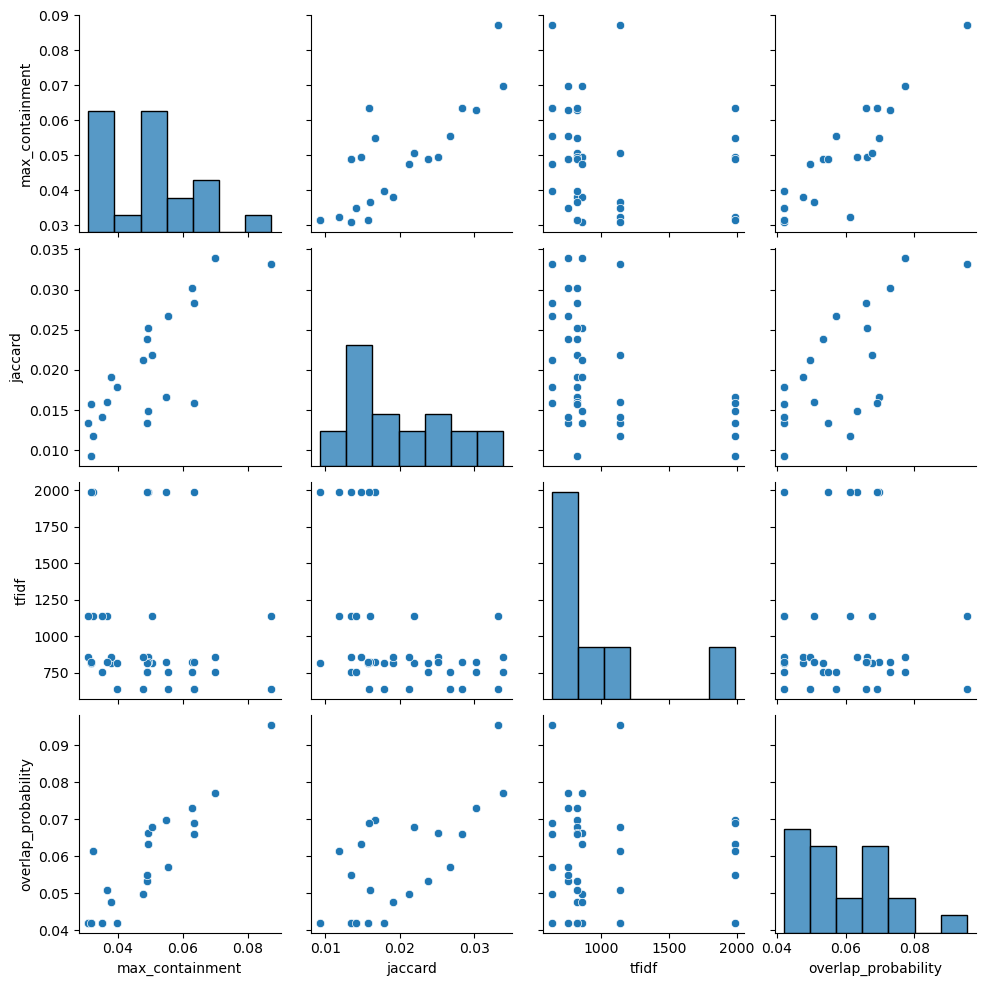

In [14]:


sns.pairplot(motif_filtered.select(['max_containment', 'jaccard', 'tfidf', 'overlap_probability']).to_pandas())

In [15]:
# Drop duplicate moltype sequences
motif_filtered_unique = motif_filtered.unique(subset=["moltype_seq"])

print(f"Original rows: {motif_filtered.select(pl.len())[0, 0]}")
print(f"After dropping duplicates: {motif_filtered_unique.select(pl.len())[0, 0]}")

with pl.Config(
    tbl_width_chars=1000,
    fmt_str_lengths=1000,
    tbl_cols=-1,
    tbl_rows=-1
):
    display(motif_filtered_unique.select(['query_name', 'target_name', 'query_subseq', 'moltype_seq', 'target_subseq', 'tfidf', 'max_containment', 'jaccard', 'overlap_probability']))

Original rows: 42
After dropping duplicates: 14


query_name,target_name,query_subseq,moltype_seq,target_subseq,tfidf,max_containment,jaccard,overlap_probability
str,str,str,str,str,f64,f64,f64,f64
"""d4gria2 a.97.1.0 (A:315-490) automated matches {Borrelia burgdorferi [TaxId: 224326]}""","""d2vfra2 d.145.1.1 (A:0-179) Alditol oxidase {Streptomyces coelicolor [TaxId: 100226]}""","""SNGFKLGEILLPIRIAALGS""","""pphhphhphhhhhphhhhhp""","""NEIAEPGDGGVLLSLAGLPS""",859.769623,0.049383,0.025157,0.066087
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d1dqna_ c.61.1.1 (A:) Guanine PRTase {Giardia intestinalis [TaxId: 5741]}""","""VNELFRDGVNWGRIVAFFSFGGAL""","""hpphhpphhphhphhhhhphhhhh""","""MNEYYKDVAEPVTLVALLTGAYLY""",636.713462,0.087302,0.033233,0.095342
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d4e2za_ c.66.1.60 (A:) TcaB9 {Micromonospora chalcea [TaxId: 1874]}""","""LFRDGVNWGRIVAFFSFGGALC""","""hhpphhphhphhhhhphhhhhp""","""YVQSVLEGVDALLAPDGVFVFE""",636.713462,0.063492,0.015905,0.068986
"""d1dqna_ c.61.1.1 (A:) Guanine PRTase {Giardia intestinalis [TaxId: 5741]}""","""d4e2za_ c.66.1.60 (A:) TcaB9 {Micromonospora chalcea [TaxId: 1874]}""","""YYKDVAEPVTLVALLTGAYLY""","""hhpphhphhphhhhhphhhhh""","""YVQSVLEGVDALLAPDGVFVF""",1139.929955,0.032407,0.011785,0.061277
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d2vfra2 d.145.1.1 (A:0-179) Alditol oxidase {Streptomyces coelicolor [TaxId: 100226]}""","""FRDGVNWGRIVAFFSFGGALCV""","""hpphhphhphhhhhphhhhhph""","""FNEIAEPGDGGVLLSLAGLPSV""",636.713462,0.063492,0.028369,0.065823
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d3alua_ d.169.1.0 (A:) automated matches {Cucumaria echinata [TaxId: 40245]}""","""RDGVNWGRIVAFFSFGGALCV""","""pphhphhphhhhhphhhhhph""","""TSLPDLITGGWAPQVYIGMKV""",636.713462,0.055556,0.026718,0.05706
"""d1ohua_ f.1.4.1 (A:) Apoptosis regulator ced-9 {Nematode (Caenorhabditis elegans) [TaxId: 6239]}""","""d1dqna_ c.61.1.1 (A:) Guanine PRTase {Giardia intestinalis [TaxId: 5741]}""","""QSPMSYGRLIGLISFGGFVA""","""pphhphhphhhhhphhhhhh""","""KDVAEPVTLVALLTGAYLYA""",818.330264,0.050633,0.021858,0.0678
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d1ohua_ f.1.4.1 (A:) Apoptosis regulator ced-9 {Nematode (Caenorhabditis elegans) [TaxId: 6239]}""","""RDGVNWGRIVAFFSFGGAL""","""pphhphhphhhhhphhhhh""","""QSPMSYGRLIGLISFGGFV""",636.713462,0.039683,0.017921,0.041971
"""d2vfra2 d.145.1.1 (A:0-179) Alditol oxidase {Streptomyces coelicolor [TaxId: 100226]}""","""d1dqna_ c.61.1.1 (A:) Guanine PRTase {Giardia intestinalis [TaxId: 5741]}""","""FNEIAEPGDGGVLLSLAGLP""","""hpphhphhphhhhhphhhhh""","""YKDVAEPVTLVALLTGAYLY""",820.107186,0.036585,0.016043,0.050735


In [21]:
# Subset to only matches where query or target has SCOP lineage f.1.4.1
f_1_4_1_matches = motif_filtered.filter(
    (pl.col("query_scop_lineage") == "f.1.4.1") &
    (pl.col("target_scop_lineage") == "f.1.4.1")
)

f_1_4_1_matches.select([
    "scop_relationship",
    "query_scop_id", 
    "query_scop_lineage",
    "target_scop_id",
    "target_scop_lineage",
    "containment",
    "jaccard",
])

scop_relationship,query_scop_id,query_scop_lineage,target_scop_id,target_scop_lineage,containment,jaccard
str,str,str,str,str,f64,f64
"""Same family""","""d7jgwa1""","""f.1.4.1""","""d1ohua_""","""f.1.4.1""",0.039683,0.017921
"""Same family""","""d1ohua_""","""f.1.4.1""","""d7jgwa1""","""f.1.4.1""",0.031646,0.017921


In [26]:
# Show full column names and content
with pl.Config(
    tbl_width_chars=1000,
    fmt_str_lengths=1000,
    tbl_cols=-1,
    tbl_rows=-1
):
    display(f_1_4_1_matches.select([
        'query_name', 
        'target_name', 
        'query_subseq', 
        'moltype_seq', 
        'target_subseq'
    ]))

query_name,target_name,query_subseq,moltype_seq,target_subseq
str,str,str,str,str
"""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""d1ohua_ f.1.4.1 (A:) Apoptosis regulator ced-9 {Nematode (Caenorhabditis elegans) [TaxId: 6239]}""","""RDGVNWGRIVAFFSFGGAL""","""pphhphhphhhhhphhhhh""","""QSPMSYGRLIGLISFGGFV"""
"""d1ohua_ f.1.4.1 (A:) Apoptosis regulator ced-9 {Nematode (Caenorhabditis elegans) [TaxId: 6239]}""","""d7jgwa1 f.1.4.1 (A:1-196) Apoptosis regulator Bcl-xL {Human (Homo sapiens) [TaxId: 9606]}""","""QSPMSYGRLIGLISFGGFV""","""pphhphhphhhhhphhhhh""","""RDGVNWGRIVAFFSFGGAL"""


In [23]:
f_1_4_1_matches.select(['query_name', 'target_name', 'query_subseq', 'moltype_seq', 'target_subseq'])

query_name,target_name,query_subseq,moltype_seq,target_subseq
str,str,str,str,str
"""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""d1ohua_ f.1.4.1 (A:) Apoptosis…","""RDGVNWGRIVAFFSFGGAL""","""pphhphhphhhhhphhhhh""","""QSPMSYGRLIGLISFGGFV"""
"""d1ohua_ f.1.4.1 (A:) Apoptosis…","""d7jgwa1 f.1.4.1 (A:1-196) Apop…","""QSPMSYGRLIGLISFGGFV""","""pphhphhphhhhhphhhhh""","""RDGVNWGRIVAFFSFGGAL"""


In [ ]:
""">tr|A0A1L8F4J2|A0A1L8F4J2_XENLA Induced myeloid leukemia cell differentiation protein Mcl-1 homolog OS=Xenopus laevis OX=8355 GN=mcl1.S PE=3 SV=1
MMHQSAIAKQRSSASLLVPCQLYCSGGASEKPASSCGVFQWDTEKHREKAERPQLNGLDF
NNGGSLPCSQDDELDEDLDSGSQGSSSPPDSPVCPKDGLYMETHRLIVAFFRTYCGEESG
GYKASCLLHHGVQHKALETLLRVGGDIIEKHHMAFTGMLQRLSINSREDLQKLSEVPALV
FNDGVTNWGRIVTVISFGAFVAKHLKSIHLEDCINNLAEYFTQFLMTSKKDWIIKEKAWE
GFVDFFHIEDYESGLKTVLMAFSSVAFLGAGLAYMIR"""

In [38]:
import kmerseek

ModuleNotFoundError: No module named 'kmerseek'